In [1]:
import sys
import os

#sys.path.insert(0, os.path.abspath('/home/vk9342/scarlet2/src'))

import scarlet2
print(scarlet2.__file__)

/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/jaxtyping/__init__.py:231: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/scarlet2/__init__.py


In [2]:
import numpy as np
import numpyro.distributions as dist
from numpyro.distributions import constraints

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
matplotlib.rc('image', cmap='gray', interpolation='none', origin='lower')

import jax


import jax.numpy as jnp
from jax import random, jit
import jax
import copy

import pandas as pd
from scipy.stats import gaussian_kde as kde
from scipy.stats import norm

# import scarlet
import scarlet2
# from scarlet.display import AsinhMapping,AsinhPercentileNorm,show_scarlet2_scene,LinearPercentileNorm
# from scarlet.source import StaticSource,MultiExtendedSource, StaticMultiExtendedSource
from scarlet2 import *
from scarlet2 import relative_step
from scarlet2 import (
    Observation, Frame, Scene, Source, PointSource,
    init, relative_step, Parameter, StaticArraySpectrum, 
    TransientArraySpectrum
)
from scarlet2 import Starlet
from scarlet2.plot import AsinhPercentileNorm


import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.wcs import WCS
from astropy.io import fits
import astropy.io.fits as fits

import sys
import copy
#import corner
import h5py
import os
import glob
import sep
from sep import Background, extract
import tarfile
import equinox as eqx
# import distrax
import optax
from tqdm.auto import tqdm
# import cmasher as cmr


from functools import partial
from skimage import draw
%matplotlib inline
# import astrophot as ap
pixelscale=0.17

# turn on automatic validation checks
from scarlet2.validation_utils import set_validation

# turn on automatic validation checks
set_validation(False)

# Load the Data + Define Observation and Frame: 
#### Get Rubin + 2 Roman observations

In [3]:
# ============================================================================
# 1. General info and file paths
# ============================================================================
img_index = 62425      # Goldstein catalog img index
oversamplefactor = 1   # if using oversampled PSF --> not fully tested though

# Paths where observations are stored
path = 'outputs/caustics/SNsims/'
data_path  = path + 'img_' + str(img_index) + '/fixed_rgb/'
psf_path   = 'PSFs/'

In [4]:
# When is the SN active
t_start = 5
t_end = 130

# Roman (high res) times to be used
t_off   = 0
t_on    = 50
n_roman_epochs = 2

# Rubin times to be used
times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]  
epochs = [int(i) for i in range(len(times))] # epoch index list



bands   = ["g","r","i"]                              # Rubin bands
BANDS   = ['f106', 'f129',  'f158']                  # Roman bands 
bandall = ['g','r','i', 'f106', 'f129',  'f158']     # all bands   

n_lsst  = len(bands) * len(times)        # e.g. 3 bands × (len(times))
n_roman  = len(BANDS) * n_roman_epochs   # 3 bands × 2 epochs = 6


channels = []      # (band name, epoch index)
channels_on = []   # (band, epoch) when the SN is active
observations = []  # list of scarlet2 Observation objects
epochs_on = []     # epochs when the SN is active


In [5]:
## ==========================================================================================================================
## 2. Get weights: copied noise function used in caustics (which is based on Lenstronomy's Gaussian noise component)
## ==========================================================================================================================

# Telescope params take from Lenstronomy github
telescope_params = {
    'LSST': {
        'read_noise': 10.0,
        'pixel_scale': 0.2, 
        'ccd_gain': 2.3,
        'exposure_time': {'g': 15.0, 'r': 15.0, 'i': 15.0},
        'sky_brightness_mags': {'g': 22.26, 'r': 21.2, 'i': 20.48},
        'zero_points_mags': {'g': 28.30, 'r': 28.13, 'i': 27.79},
        'num_exposures': {'g': 200, 'r': 460, 'i': 460},
        'seeing': {'g':0.77, 'r':0.73, 'i':0.71}
    },
    'Roman': {
        'read_noise': 15.5,
        'pixel_scale': 0.11, 
        'ccd_gain': 1,
        'sky_brightness_mags': {'f062': 23.19, 'f087': 22.93, 'f106':22.99, 'f129':22.99, 'f158':23.10, 'f184':23.22, 'f146':22.03},
        'zero_points_mags': {'f062':26.6179, 'f087': 26.3023, 'f106': 26.3546, 'f129':26.3531, 'f158':26.3760, 'f184':25.9124, 'f146':27.5842},
        'seeing': {'f062': 0.058, 'f087':0.073, 'f106':0.087, 'f129': 0.106, 'f158':0.128, 'f184':0.146, 'f146':0.105},
        'exposure_time': {'f062':60, 'f087': 85, 'f106': 95, 'f129': 152, 'f158': 294, 'f184': None, 'f146':None},
        'num_exposures':  {'f062':1, 'f087': 1,   'f106': 1,   'f129': 1,   'f158': 1,   'f184': None, 'f146':None}
    }
}

def gaussian_noise_sigma(
    image, 
    readout_noise,   # have read noise param value,     in counts (e.g. e-)?
    exposure_time,   # have exposure time param value,  in seconds?
    sky_brightness,  # have sky brightness param value, in magnitudes/arcsec^2
    pixel_scale,     # have pixel scale param value,    in arcsec
    num_exposures,   # have num exposures param value,  unitless
    magnitude_zero_point
):
    '''
    background_noise: Gaussian sigma of noise level per pixel in counts (e- or ADU) per second.
    Im assuming we're using e- and not ADU
    '''
    
    # Convert Sky Magnitude to Counts/sec/arcsec^2 (conversion from Lenstronomy)
    sky_brightness_counts_arcsec2 = 10 ** (-(sky_brightness - magnitude_zero_point) / 2.5)

    exposure_time_tot = num_exposures * exposure_time
    readout_noise_tot = num_exposures * readout_noise**2  # square of readout noise
    sky_per_pixel = sky_brightness_counts_arcsec2 * pixel_scale**2
    sky_brightness_tot = exposure_time_tot * sky_per_pixel
    
    sigma_bkg = np.sqrt(readout_noise_tot + sky_brightness_tot) / exposure_time_tot

    return sigma_bkg


In [6]:
# ============================================================================
# 3. Load Observations for each Rubin epoch
# ============================================================================

# Make list of Observation objects --> one for each Rubin band and epoch
for ind_b, band in enumerate(bands):       
    for ind_t, epoch in enumerate(times):
        
        channel_sc2 = (band, int(ind_t)) #channels are (band name str, epoch index int)


        # ============================================================================
        ### Modify as needed for user data (observations, PSFs, WCS, weights if used):

        
        # get indecies of high res Roman times being used
        if epoch == t_on:
            ind_t_on = str(ind_t)
        elif epoch == t_off:
            ind_t_off = str(ind_t)
        
        # get channels for only 'on' SN times
        if epoch >= t_start and epoch <t_end:  
            channels_on.append(channel_sc2)
            epochs_on.append(int(ind_t))

        
        # Caustics image simulation files (fits)
        data_file_name = 'image_LSST_'+band+'_'+str(img_index)+'_SNnoise_'+str(epoch)+'.0.fits' 
        img = data_path+ data_file_name

        obs_hdu = fits.open(img)
        data_lsst = obs_hdu[0].data
        data_lsst = data_lsst.astype(data_lsst.dtype.newbyteorder('=')) ## Do I sill need this?
        N1, N2 = data_lsst.shape
        data_lsst = data_lsst.reshape(1, N1, N2) #reshape because?

        # WCS - saved as header of fits files, made manually in Caustics
        wcs_lsst = WCS(obs_hdu[0].header)

        # PSF data - npy files with gaussians, made manually in Caustics
        psf_data = np.load(psf_path + f'caustics_gaussian_psf_LSST_{band}_size_17.npy')
        psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
        psf_lsst = scarlet2.ArrayPSF(psf_jax)

        
        ## Recalculate added noise (added on top of Caustics image before saving .fits files)
        params = telescope_params['LSST']
        noise_sigma = gaussian_noise_sigma(
            image = data_lsst,
            readout_noise = params['read_noise'],
            exposure_time = params['exposure_time'][band],
            sky_brightness = params['sky_brightness_mags'][band],
            pixel_scale = params['pixel_scale'],
            num_exposures = params['num_exposures'][band],
            magnitude_zero_point = params['zero_points_mags'][band]
        )
        weights_lsst = jnp.ones_like(data_lsst) / (noise_sigma**2)
        # print(noise_sigma)
        # ============================================================================

        
        # Make observations
        obs_lsst = scarlet2.Observation(jnp.asarray(data_lsst),
                                      wcs=wcs_lsst,
                                      psf=psf_lsst,
                                      channels=[channel_sc2],
                                      weights=weights_lsst)
        observations.append(obs_lsst)
        channels.append(channel_sc2)


In [7]:
print(wcs_lsst)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 15.5 15.5 
PC1_1 PC1_2  : -5.5555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 5.5555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 30  30


In [8]:
# ============================================================================================================
# 4. Load high-res off/on images for Roman and add to 'observations' list of scarlet2.Observatios
# ============================================================================================================

### Read in a single epoch of high resolution imaging WITHOUT the SN
for ind_b, (band, BAND) in enumerate(zip(bands, BANDS)):

    channel_sc2 = (BAND, int(ind_t_off))
    epoch = t_off
    
    data_file_name = 'image_Roman_'+BAND+'_'+str(img_index)+'_SNnoise_'+str(t_off)+'.0.fits' 
    img = data_path+ data_file_name

    obs_hdu = fits.open(img)
    data_roman = obs_hdu[0].data
    data_roman = data_roman.astype(data_roman.dtype.newbyteorder('='))
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2) 
    wcs_roman = WCS(obs_hdu[0].header)

    psf_data = np.load(psf_path + f'caustics_gaussian_psf_Roman_{BAND}_size_17.npy')
    psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
    psf_roman = scarlet2.ArrayPSF(psf_jax)

    ## Recalculate added noise
    params = telescope_params['Roman']
    noise_sigma = gaussian_noise_sigma(
        image = data_roman,
        readout_noise = params['read_noise'],
        exposure_time = params['exposure_time'][BAND],
        sky_brightness = params['sky_brightness_mags'][BAND],
        pixel_scale = params['pixel_scale'],
        num_exposures = params['num_exposures'][BAND],
        magnitude_zero_point = params['zero_points_mags'][BAND]
    )
    weights_roman = jnp.ones_like(data_roman) / (noise_sigma**2)
    print(noise_sigma)

    # define two observation packages and match to frame
    obs_roman_offSN = scarlet2.Observation(data_roman,
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights= weights_roman)   
    
    channels.append(channel_sc2)
    observations.append(obs_roman_offSN)



### Read in a single epoch of high resolution imaging WITH the SN
for ind_b, (band, BAND) in enumerate(zip(bands, BANDS)):
    
    channel_sc2 = (BAND, int(ind_t_on))
    epoch = t_on
    
    data_file_name = 'image_Roman_'+BAND+'_'+str(img_index)+'_SNnoise_'+str(t_on)+'.0.fits' 
    img = data_path+ data_file_name

    obs_hdu = fits.open(img)
    data_roman = obs_hdu[0].data
    data_roman = data_roman.astype(data_roman.dtype.newbyteorder('=')) 
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2) #reshape because?
    wcs_roman = WCS(obs_hdu[0].header)
    print(wcs_roman)
    # data_roman_offSN = jnp.array(np.asarray(data_roman,dtype=float), jnp.float32)

    psf_data = np.load(psf_path + f'caustics_gaussian_psf_Roman_{BAND}_size_17.npy')
    psf_jax = jnp.asarray([psf_data.astype('float32')]/np.sum(psf_data.astype('float32')))
    psf_roman = scarlet2.ArrayPSF(psf_jax)
    print(np.sum(psf_roman))
    ## Recalculate added noise
    params = telescope_params['Roman']
    noise_sigma = gaussian_noise_sigma(
        image = data_roman,
        readout_noise = params['read_noise'],
        exposure_time = params['exposure_time'][BAND],
        sky_brightness = params['sky_brightness_mags'][BAND],
        pixel_scale = params['pixel_scale'],
        num_exposures = params['num_exposures'][BAND],
        magnitude_zero_point = params['zero_points_mags'][BAND]
    )
    weights_roman = jnp.ones_like(data_roman) / (noise_sigma**2)
    print(noise_sigma)
    

    channels_on.append(channel_sc2)
    epochs_on.append(int(ind_t_on))
    
    # define two observation packages and match to frame
    obs_roman_postSN = scarlet2.Observation(jnp.asarray(data_roman),
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights=weights_roman) 
    
    channels.append(channel_sc2)
    observations.append(obs_roman_postSN)


0.17159469598490368
0.11027849283278497
0.06017137680885486
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55
ArrayPSF(morphology=f32[1,17,17])
0.17159469598490368
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55
ArrayPSF(morphology=f32[1,17,17])
0.11027849283278497
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55
ArrayPSF(morphology=f32[1,17,17])
0.06017137680885486


In [9]:
# How many observations did we end up reading in?
print(len(observations))
print(channels)
bandind = np.unique([x[0] for x in channels],return_index=True)
print(bandind[1])


54
[('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('g', 15), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('r', 15), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('i', 15), ('f106', 0), ('f129', 0), ('f158', 0), ('f106', 8), ('f129', 8), ('f158', 8)]
[48 49 50  0 32 16]


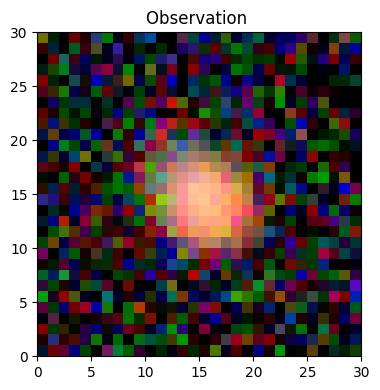

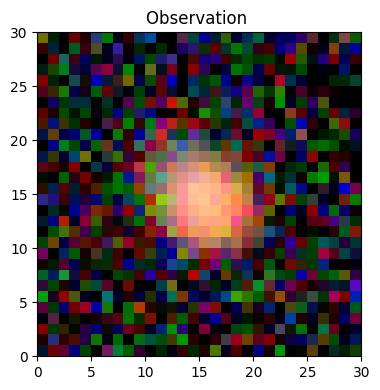

In [10]:
# =============================================
# Plot Rubin Observaton in RGB 
# =============================================
rgb_data = []
rgb_weights = []
rgb_psfs = []
rgb_channels = []
rgb_wcs = None

target_epoch = times[0] 
for band in bands: 
    data_file_name = f'image_LSST_{band}_{img_index}_SNnoise_{target_epoch}.0.fits'
    img_path = data_path + data_file_name
    with fits.open(img_path) as hdul:
        if band == 'g':
            rgb_wcs = WCS(hdul[0].header)

        d = hdul[0].data.astype('float32')
        rgb_data.append(d)
        params = telescope_params['LSST']
        noise_sigma = gaussian_noise_sigma(
            image=d,
            readout_noise=params['read_noise'],
            exposure_time=params['exposure_time'][band],
            sky_brightness=params['sky_brightness_mags'][band],
            pixel_scale=params['pixel_scale'],
            num_exposures=params['num_exposures'][band],
            magnitude_zero_point=params['zero_points_mags'][band]
        )
        rgb_weights.append(np.ones_like(d) / (noise_sigma**2))
        rgb_psf_data = np.load(psf_path + f'caustics_gaussian_psf_LSST_{band}_size_17.npy')
        rgb_psf_norm = rgb_psf_data.astype('float32') / np.sum(rgb_psf_data)
        rgb_psfs.append(scarlet2.ArrayPSF(jnp.array(rgb_psf_norm)))
        rgb_channels.append((band, target_epoch))
        
rgb_combined_obs = scarlet2.Observation(
    jnp.array(rgb_data),
    weights=jnp.array(rgb_weights),
    psf=rgb_psfs[0],
    wcs=rgb_wcs,
    channels=rgb_channels
)
norm = scarlet2.plot.AsinhAutomaticNorm(rgb_combined_obs)
scarlet2.plot.observation(rgb_combined_obs, norm=norm, add_labels=False, show_psf=False)

In [11]:
# ============================================================================
# 5. Make Model Frame and Match Observations to it
# ============================================================================
# model_frame_psf = scarlet2.GaussianPSF(0.7)  # defaults to PSF of size 0.7 if not specified

model_frame = scarlet2.Frame.from_observations(
    observations=observations,
    coverage="union"  # or "intersection"
    )

for obs in observations:
    obs.match(model_frame)

# Find Sources (SEP)

In [12]:
# ============================================================================
# 6. Find sourced in image - from RubinRoman_TD notebook
# ============================================================================

def makeCatalog(observations, lvl=3, wave=True, SNR=2.0):
    
    normed_images = np.asarray([obs.data[0] for obs in observations])
    interps = normed_images
    
    interps = np.asarray(interps/np.sum(interps))
    detect_image = np.sum(interps,axis=(0))
    # Wavelet transform
    # wave_detect = scarlet.Starlet.from_image(detect_image).coefficients
    wave_detect = Starlet.from_image(detect_image).coefficients

    if wave:
        # Creates detection from the first 3 wavelet levels
        detect = wave_detect[:lvl,:,:].sum(axis = 0)
    else:
        detect = detect_image

    detect = np.array(detect)

    # Runs SEP detection
    bkg = sep.Background(detect)
    catalog = sep.extract(detect-bkg.globalback, SNR, err=bkg.globalrms)
    background=[]
    bg_rms=[]
    for ind in range(len(observations)):
        img = copy.copy(np.asarray(observations[ind].data))
        if np.size(img.shape) == 3:
            bg_rms.append(np.array([sep.Background(band).globalrms for band in img]))
            background.append(np.array([sep.Background(band).globalback for band in img]))
        else:
            bg_rms.append(sep.Background(img).globalrms)
            background.append(sep.Background(img).globalback)
    return catalog, bg_rms, detect_image, background

In [13]:
# ============================================================================
# 7. Find sources in image - from RubinRoman_TD notebook
# ============================================================================

#If the source detection is not finding all the sources, you can first try to adjust these three parameters to help it find the sources
lvl=2
wave=2
SNR=5.0  # was 2

lsst_obs = observations[:-n_roman]
roman_obs = observations[-n_roman:]

observations_sc2=[]
normsingle=[]

# ============================================================================   
# DETECT SOURCES BASED ONLY ON HIGH RES ROMAN IMGS 

catalog_single_roman, bgsingle_roman, detectsingle_roman, globalback_roman = makeCatalog(roman_obs, lvl, wave, SNR)
pixel = np.stack((catalog_single_roman['y'], catalog_single_roman['x']), axis=1)
ra_dec = pixel
print(ra_dec.shape)
# ============================================================================

(3, 2)


In [14]:
# ============================================================================
# 8. Make observations_sc2 
# ============================================================================

bgarr_roman     = np.asarray(bgsingle_roman)
bgarrall_roman  = np.hstack((bgarr_roman.flatten(),np.asarray(bgsingle_roman).flatten()))
bgarr_roman     = np.asarray(bgsingle_roman)
print(bgarrall_roman.shape)

catalog_single_lsst, bgsingle_lsst, detectsingle_lsst, globalback_lsst = makeCatalog(lsst_obs, lvl, wave, SNR)
bgarr_lsst    = np.asarray(bgsingle_lsst)
bgarrall_lsst = np.hstack((bgarr_lsst.flatten(),np.asarray(bgsingle_lsst).flatten()))
bgarr_lsst    = np.asarray(bgsingle_lsst)
print(bgarrall_lsst.shape)


bgr_lsst = np.array([b[0] for b in bgarr_lsst])
bgr_roman = np.array([b[0] for b in bgarr_roman])
bgarr_all = np.concatenate([bgr_lsst, bgr_roman], axis=0)

gb_lsst = np.array([b[0] for b in globalback_lsst])
gb_roman = np.array([b[0] for b in globalback_roman])
globalback_all = np.concatenate([gb_lsst, gb_roman], axis=0)

print(len(bgarr_all))
print(len(globalback_all))


for ind,(obs2, bg, back) in enumerate(zip(observations, bgarr_all, globalback_all)):

    print(ind)
    
    w = obs2.frame.wcs
    psf = obs2.frame.psf
    weights2=np.ones(obs2.data.shape) / (bg**2)#[:, None, None]  #??in RubinRoman notebook insteads of bg it uses bgarr_all, is this a typo?
    data = obs2.data-back   #Subtract background flux

    print(channels[ind])
    
    obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf,channels=[channels[ind]],wcs=w)
    observations_sc2.append(obs_sc2)
    # print("obs2.data shape:", obs2.data.shape, '\n')
    # print('obs2.data: ', obs2.data, '\n')
    # print('obs2.data[:,10:-10,10:-10]:', obs2.data[:,10:-10,10:-10], '\n')

    
    #Store norm based on observation data
    normsingle.append(
        AsinhPercentileNorm(
            jnp.asarray(np.asarray((obs2.data[:,10:-10,10:-10]),dtype=np.float32)),
            percentiles=[0.001, 50, 80])
    )



(12,)
(96,)
54
54
0
('g', 0)
1
('g', 1)
2
('g', 2)
3
('g', 3)
4
('g', 4)
5
('g', 5)
6
('g', 6)
7
('g', 7)
8
('g', 8)
9
('g', 9)
10
('g', 10)
11
('g', 11)
12
('g', 12)
13
('g', 13)
14
('g', 14)
15
('g', 15)
16
('r', 0)
17
('r', 1)
18
('r', 2)
19
('r', 3)
20
('r', 4)
21
('r', 5)
22
('r', 6)
23
('r', 7)
24
('r', 8)
25
('r', 9)
26
('r', 10)
27
('r', 11)
28
('r', 12)
29
('r', 13)
30
('r', 14)
31
('r', 15)
32
('i', 0)
33
('i', 1)
34
('i', 2)
35
('i', 3)
36
('i', 4)
37
('i', 5)
38
('i', 6)
39
('i', 7)
40
('i', 8)
41
('i', 9)
42
('i', 10)
43
('i', 11)
44
('i', 12)
45
('i', 13)
46
('i', 14)
47
('i', 15)
48
('f106', 0)
49
('f129', 0)
50
('f158', 0)
51
('f106', 8)
52
('f129', 8)
53
('f158', 8)


In [15]:
### Debugging inhomogeneous part error
# for i, obs in enumerate(observations):
#     print(f"Index {i} -> obs.data[0] shape: {obs.data[0].shape}")

In [16]:
# ============================================================================
# 9. Make new Model Frame and Match observations_sc2 to it
# ============================================================================
model_frame = scarlet2.Frame.from_observations(
    observations=observations_sc2,
    model_psf = scarlet2.GaussianPSF(sigma = 0.3),    # model_psf sigma smaller than sigma of all observations' PSFs
    coverage="union",  # or "intersection"
)


In [17]:
# If using oversampled PSF (currently oversamplefactor = 1 so does nothing)
print(model_frame)

wcs_roman_oversampled = copy.deepcopy(model_frame.wcs)
wcs_roman_oversampled.wcs.crpix = model_frame.wcs.wcs.crpix*oversamplefactor 
wcs_roman_oversampled.wcs.pc = model_frame.wcs.wcs.pc/oversamplefactor 
wcs_roman_oversampled._naxis[-1] = model_frame.wcs._naxis[-1]*oversamplefactor
wcs_roman_oversampled._naxis[-2] = model_frame.wcs._naxis[-2]*oversamplefactor

bbox_roman_oversampled = copy.deepcopy(model_frame.bbox)
# bbox_roman_oversampled.shape = (bbox_roman_oversampled.shape[-3],bbox_roman_oversampled.shape[-2]*oversamplefactor,bbox_roman_oversampled.shape[-1]*oversamplefactor)

#print(wcs_roman_oversampled)
object.__setattr__(model_frame,'wcs', wcs_roman_oversampled)
object.__setattr__(model_frame,'bbox', bbox_roman_oversampled)
print(model_frame)

norm_corr = []
for i, obs in enumerate(observations_sc2):
    ## Uncomment if using ovsersampled PSFs:
    # if i<n_lsst:
    #     obs_corr = scarlet2.CorrelatedObservation.from_observation(obs,resample_to_frame=model_frame)#,resample_psf=True)
    # else:
    #     obs_corr = scarlet2.CorrelatedObservation.from_observation(obs,resample_to_frame=model_frame,resample_psf=False,lanczos_order=21)
    
    obs_corr = scarlet2.CorrelatedObservation.from_observation(obs,resample_to_frame=model_frame, resample_psf=True)   # fitting with CorrelatedObservation is much faster
    norm_c= scarlet2.plot.AsinhAutomaticNorm(obs_corr)
    norm_corr.append(norm_c)
    
    obs_corr.match(model_frame)
    observations_sc2[i] = obs_corr

Frame(
  bbox=Box(shape=(54, 55, 55), origin=(0, 0, 0)),
  psf=GaussianPSF(morphology=GaussianMorphology(size=0.3, ellipticity=None)),
  wcs=WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 28.0 28.0 
PC1_1 PC1_2  : -3.0555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 3.0555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 55  55,
  channels=[
    ('g', 0),
    ('g', 1),
    ('g', 2),
    ('g', 3),
    ('g', 4),
    ('g', 5),
    ('g', 6),
    ('g', 7),
    ('g', 8),
    ('g', 9),
    ('g', 10),
    ('g', 11),
    ('g', 12),
    ('g', 13),
    ('g', 14),
    ('g', 15),
    ('r', 0),
    ('r', 1),
    ('r', 2),
    ('r', 3),
    ('r', 4),
    ('r', 5),
    ('r', 6),
    ('r', 7),
    ('r', 8),
    ('r', 9),
    ('r', 10),
    ('r', 11),
    ('r', 12),
    ('r', 13),
    ('r', 14),
    ('r', 15),
    ('i', 0),
    ('i', 1),
    ('i', 2),
    ('i', 3),
    ('i', 4),
    ('i', 5),
    ('i', 6),
    ('i', 7),
    ('i', 8),
    ('i', 9),
    ('i', 10),
    ('i', 11),

# Detected Sources

In [18]:
# ============================================================================
# 10. Source initialization
# ============================================================================
lsst_obs_sc2 = observations_sc2[:-n_roman]   
roman_obs_sc2 = observations_sc2[-n_roman:]

band_selector  = lambda ch: ch[0]
epoch_selector = lambda ch: ch[1]


In [19]:
world_coords = []
for y, x in ra_dec:
    sky = wcs_roman.pixel_to_world(x, y)   # note: pixel_to_world(x, y)
    world_coords.append(SkyCoord(sky.ra, sky.dec))

roman_pixel_coords = [wcs_roman.world_to_pixel(sky) for sky in world_coords]
lsst_pixel_coords = [wcs_lsst.world_to_pixel(sky) for sky in world_coords]

## Ra and dec centers from SEP catalog
sky_coords_ = world_coords      

In [20]:
print("Detected source pixel coordinates:")
for i, (y, x) in enumerate(ra_dec, start=1):
    print(f"  Source {i:>2d}: x = {x:.2f}, y = {y:.2f}")

print("\nDetected source sky coordinates:")
for i, sky in enumerate(world_coords, start=1):
    # in decimal degrees:
    print(f"  Source {i:>2d}: RA = {sky.ra.deg:.6f}°,  Dec = {sky.dec.deg:.6f}°")

print("\nBack to LSST pixel coords:")
for i, (x_lsst, y_lsst) in enumerate(lsst_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_lsst:.2f},  y = {y_lsst:.2f}")

print("\nBack to Roman pixel coords:")
for i, (x_roman, y_roman) in enumerate(roman_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_roman:.2f},  y = {y_roman:.2f}")


Detected source pixel coordinates:
  Source  1: x = 26.86, y = 27.10
  Source  2: x = 29.75, y = 23.84
  Source  3: x = 31.38, y = 27.76

Detected source sky coordinates:
  Source  1: RA = 0.000004°,  Dec = 0.000003°
  Source  2: RA = 359.999916°,  Dec = -0.000096°
  Source  3: RA = 359.999866°,  Dec = 0.000023°

Back to LSST pixel coords:
 Source 1:  x = 14.42,  y = 14.56
 Source 2:  x = 16.01,  y = 12.76
 Source 3:  x = 16.91,  y = 14.92

Back to Roman pixel coords:
 Source 1:  x = 26.86,  y = 27.10
 Source 2:  x = 29.75,  y = 23.84
 Source 3:  x = 31.38,  y = 27.76


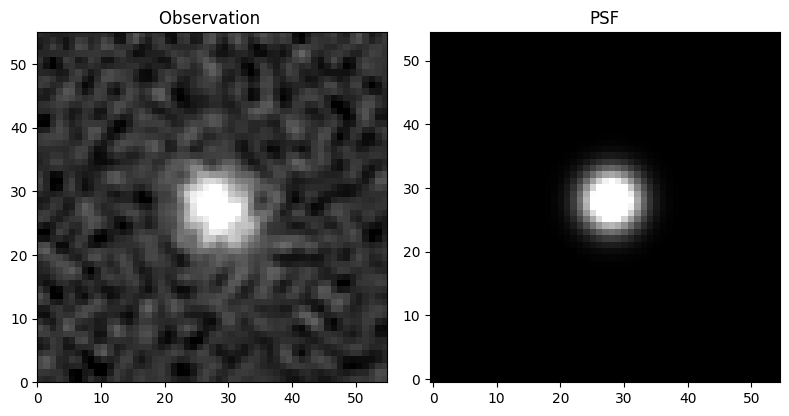

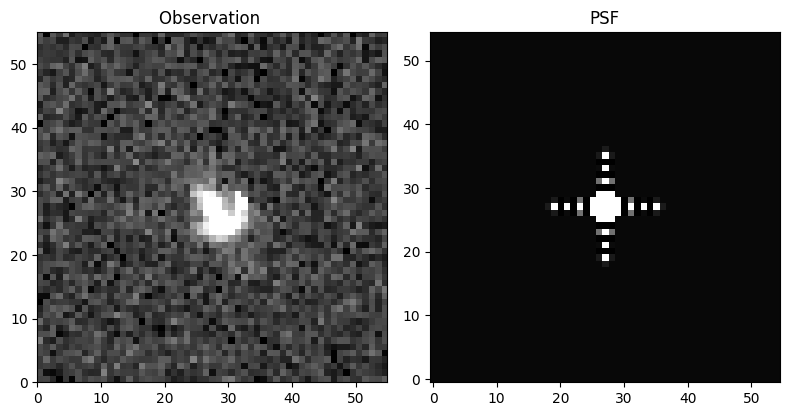

"\n# get current axis\nax = plt.gca()\n\n# loop over sources and draw both red circle and index label\nfor i, (x0, y0) in enumerate(roman_pixel_coords):\n    x0, y0 = float(x0), float(y0)\n\n    # Draw red circle\n    ax.scatter(\n        x0, y0,\n        s=80,\n        edgecolors='red',\n        facecolors='none',\n        linewidths=2\n    )\n\n    # Add index label\n    ax.text(\n        x0, y0,\n        str(i),\n        color='red',\n        fontsize=5,\n        ha='center',\n        va='center',\n        weight='bold'\n    )\n\nplt.show()\n"

In [21]:
# ============================================================================
# 11. Get and visualize sources in image
# ============================================================================
scarlet2.plot.observation(
    observation=observations_sc2[8],
    norm=None,
    channel_map=None,
    show_psf=True,
    add_labels=False,
)
plt.show()


scarlet2.plot.observation(
    observation=observations_sc2[51],
    norm=None,
    channel_map=None,
    show_psf=True,
    add_labels=False,
)
plt.show()

#plt.imshow(np.log(observations[53].frame.psf()[0]))
#plt.show()
'''
# get current axis
ax = plt.gca()

# loop over sources and draw both red circle and index label
for i, (x0, y0) in enumerate(roman_pixel_coords):
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=2
    )

    # Add index label
    ax.text(
        x0, y0,
        str(i),
        color='red',
        fontsize=5,
        ha='center',
        va='center',
        weight='bold'
    )

plt.show()
'''

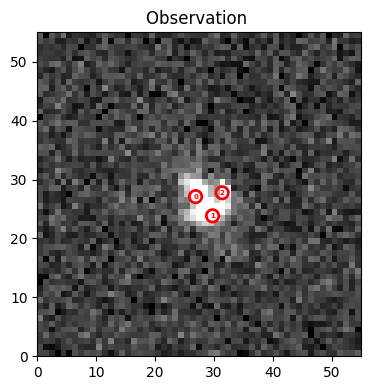

In [22]:
scarlet2.plot.observation(
    observation=observations_sc2[51],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)
#plt.imshow(np.log(observations[53].frame.psf()[0]))
#plt.show()
# get current axis
ax = plt.gca()

# loop over sources and draw both red circle and index label
for i, (x0, y0) in enumerate(roman_pixel_coords):
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=2
    )

    # Add index label
    ax.text(
        x0, y0,
        str(i),
        color='red',
        fontsize=5,
        ha='center',
        va='center',
        weight='bold'
    )

plt.show()


In [23]:
# ============================================================================
# 12. Modify source detections if needed
# ============================================================================

roman_obs_sc2_on = roman_obs_sc2[-1]
_, H, W   = roman_obs_sc2_on.data.shape               # data.shape = (C, H, WT
center_pix = np.array([W//2, H//2], dtype=int)        # [x_center, y_center] in Roman coords --> add sources slightly offset from center if not all detected


sky_coords = sky_coords_ 
# Modify as needed:
# (If a source is missing I add a source to 'sky_coords' at an approximate location, or if unknown then just slightly offset from the center)
# del sky_coords[3]
# is_extended = [False, True, True, False]   # which sources are extended and which are point sources
# lens_indx = 2                              # which source is the lens galaxy --> defining this not necessary for sc2, but helpful

if img_index == 62425:
    # del sky_coords[2]
    sky_coords = sky_coords + [sky_coords[0]] # add PS at same location as 3rd source ie lens
    is_extended = [True, True, False, False]
    lens_indx = 0

print(sky_coords, '\n')
for i, sky_coord in enumerate(sky_coords):
    print(f"Source {i} at pixel {wcs_lsst.world_to_pixel(sky_coord)}, centre is {center_pix}")

print(is_extended)
    

[<SkyCoord (ICRS): (ra, dec) in deg
    (4.20290996e-06, 3.15410078e-06)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.9999159, -9.64427255e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99986621, 2.32063971e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (4.20290996e-06, 3.15410078e-06)>] 

Source 0 at pixel (array(14.42434762), array(14.55677381)), centre is [27 27]
Source 1 at pixel (array(16.01373798), array(12.76403094)), centre is [27 27]
Source 2 at pixel (array(16.90828387), array(14.91771515)), centre is [27 27]
Source 3 at pixel (array(14.42434762), array(14.55677381)), centre is [27 27]
[True, True, False, False]


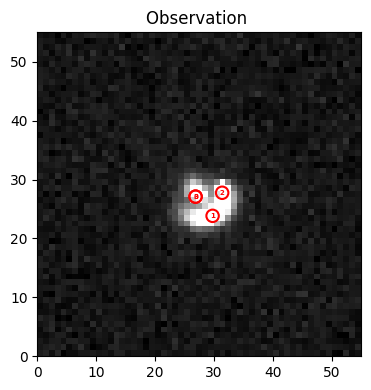

In [24]:
# Make sure all source detections are correct

scarlet2.plot.observation(
    observation=observations[53],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)


ax = plt.gca()
for i, sky_coord_i in enumerate(sky_coords):          # loop over sources and draw both red circle and index label
    x0, y0 = wcs_roman.world_to_pixel(sky_coord_i)
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=1.5
    )

    # Add index label
    ax.text(
        x0, y0,
        str(i),
        color='red',
        fontsize=5,
        ha='center',
        va='center',
        weight='bold'
    )

plt.show()

In [25]:
print(channels)
# print(epochs)
print(channels_on)
print(bandind)

[('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('g', 15), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('r', 15), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('i', 15), ('f106', 0), ('f129', 0), ('f158', 0), ('f106', 8), ('f129', 8), ('f158', 8)]
[('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('f106', 8), ('f129'

# Initialize Sources

In [26]:
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

In [32]:
# ============================================================================
# 13. Source initialization (point vs extended + Gaussian‐moment sizes)
# ============================================================================
## Build the Scarlet Scene with one Source per detection


with Scene(model_frame) as scene:
    for i, coords  in enumerate(sky_coords):

        # ============================================================================
        # EXTENDED SOURCE (e.g. host and lens galaxy) 
        if is_extended[i]:
            
            print(f"Source {i}: EXTENDED ")
            if i == lens_indx: 
                print('lens')
            else:
                print('host')
            try: 
                print('trying from_gaussian_moments')
                x0_roman, y0_roman = wcs_roman_oversampled.world_to_pixel(coords)
                x0_roman, y0_roman = float(x0_roman), float(y0_roman)
                spectrum_roman, morphology_roman = init.from_gaussian_moments(
                    roman_obs_sc2, 
                    coords,
                    min_snr = 4,
                    box_sizes=[15, 15] if i == lens_indx else [20, 20]
                    
                )
                morphology = morphology_roman
                
            ## Use gaus2d if gaussian moments fails; modify size as needed
            except IndexError:
                print('Using gaus2d')
                if i == lens_indx:
                    x = np.linspace(-20, 20, 40)
                    y = np.linspace(-20, 20, 40)
                    x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
                    morphology = gaus2d(x, y, sx=2,sy=2) 
                        
                else:
                    x = np.linspace(-20, 20, 40)
                    y = np.linspace(-20, 20, 40)
                    x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
                    morphology = gaus2d(x, y, sx=3, sy=3)
                    

            try:
                x0_lsst, y0_lsst = wcs_lsst.world_to_pixel(coords)
                x0_lsst, y0_lsst = float(x0_lsst), float(y0_lsst)
                spectrum_lsst, morphology_lsst = init.from_gaussian_moments(
                    lsst_obs_sc2, 
                    coords,#(x0_lsst, y0_lsst),
                    min_snr = 5
                )
            except:
                spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)
                #spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)

            
            print('morphology.shape before padding: ', morphology.shape)
           
            # Pad source boxes if too small
            if i == lens_indx:                      
                pad = int((15 - morphology.shape[0])/2)
            else:     
                pad = int((20 - morphology.shape[0])/2)
            
            pad = np.clip(pad, a_min=0, a_max = 100)
            morph = np.pad(morphology,(pad, pad), 'constant')
            morph[morph<1e-8]=1e-8
            # morph = scarlet2.StarletMorphology.from_image(morph)    # --> more stable fitting, but not tested yet, may need some modifications to run properly
            morph = jnp.asarray(morph)
            
            print('morphology.shape after padding: ', morph.shape)
            
            ## join lsst and roman fluxes
            # fluxes = np.hstack((spectrum_lsst,0.1*spectrum_roman))[:6]#[bandind[1]]  
            g_0, r_0, i_0 = spectrum_lsst[0], spectrum_lsst[16], spectrum_lsst[32]
            f106_0, f129_0, f158_0 = spectrum_roman[0], spectrum_roman[1], spectrum_roman[2]
            fluxes = np.array([g_0, r_0, i_0, 
                               0.1 * f106_0, 0.1 * f129_0, 0.1 * f158_0])
                               # f106_0, f129_0, f158_0])
                        
            fluxes[fluxes<1e-6]=1e-6
            print(fluxes,bandall)
            
            ## Fit StaticArraySpectrum to source
            static_spectrum = scarlet2.StaticArraySpectrum(
                    fluxes,
                    bands=bandall,
                    band_selector=band_selector
                )  
            scarlet2.Source(coords, static_spectrum, morph)
        
        # ============================================================================
        # POINT SOURCE (transient/SN) —
        else:
            print(f"Source {i}: POINT SOURCE")
            spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)  
            spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)  
            # the above returns arrays containing fluxes for ALL images, but sets the roman/lsst image fluxes to 0 in spectrum_lsst/roman
            spectrum_lsst = spectrum_lsst[:n_lsst]
            spectrum_roman = spectrum_roman[n_lsst:]
            flux_var = np.hstack((spectrum_lsst, spectrum_roman))
            flux_var[flux_var<1e-6]=np.median(flux_var)  
            flux_var[np.isnan(flux_var)]=1e-6 

            # Set 'off' epoch flux to 0 (small value)
            for j, (band, epoch) in enumerate(channels):
                if epoch not in epochs_on:
                    flux_var[j] = 1e-10  # Or 0.0 
                if epoch in epochs_on:
                    flux_var[j] = flux_var[j] * 10
    
            flux = jnp.asarray(flux_var)
            print(flux)

            transient_spectrum = scarlet2.TransientArraySpectrum(
                    flux,
                    epochs=epochs_on,   #epochs, 
                    epoch_selector=epoch_selector
                )
            scarlet2.PointSource(coords, transient_spectrum)
            

# By now `scene.sources` contains point/transient sources and extended source(s).
print(scene)


Source 0: EXTENDED 
lens
trying from_gaussian_moments
Channel '('g', 0)' not found in observations. Setting amplitude to 0.
Channel '('g', 1)' not found in observations. Setting amplitude to 0.
Channel '('g', 2)' not found in observations. Setting amplitude to 0.
Channel '('g', 3)' not found in observations. Setting amplitude to 0.
Channel '('g', 4)' not found in observations. Setting amplitude to 0.
Channel '('g', 5)' not found in observations. Setting amplitude to 0.
Channel '('g', 6)' not found in observations. Setting amplitude to 0.
Channel '('g', 7)' not found in observations. Setting amplitude to 0.
Channel '('g', 8)' not found in observations. Setting amplitude to 0.
Channel '('g', 9)' not found in observations. Setting amplitude to 0.
Channel '('g', 10)' not found in observations. Setting amplitude to 0.
Channel '('g', 11)' not found in observations. Setting amplitude to 0.
Channel '('g', 12)' not found in observations. Setting amplitude to 0.
Channel '('g', 13)' not found in 

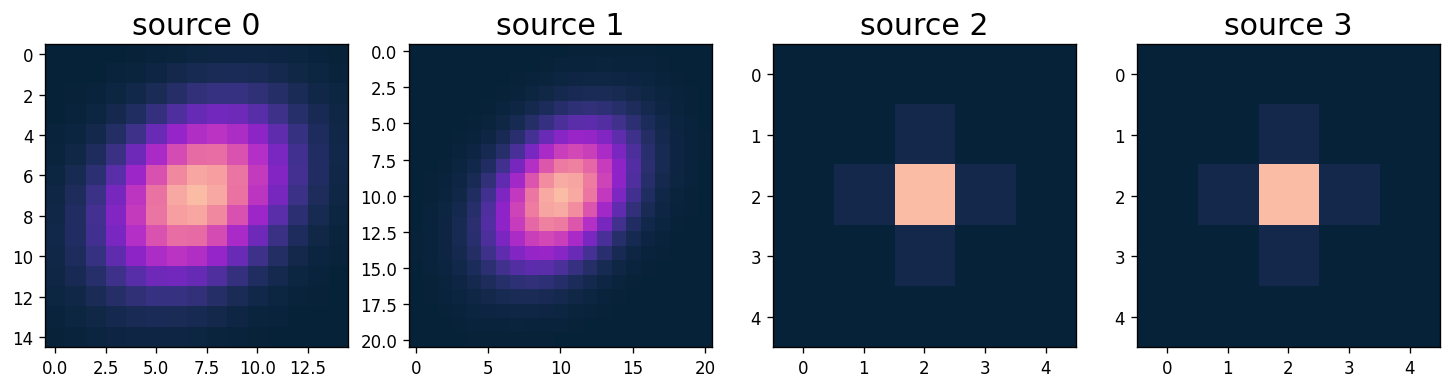

<Figure size 640x480 with 0 Axes>

In [33]:
# Plot Sources

import cmasher as cmr
cmap = cmr.bubblegum
int_method='none'
fig, axes = plt.subplots(1, len( scene.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if is_extended[i]==True:
        y = np.array(scene.sources[i].morphology)
    else:
        y = scene.sources[i].morphology()
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    ax.invert_yaxis()

plt.show()
plt.clf()

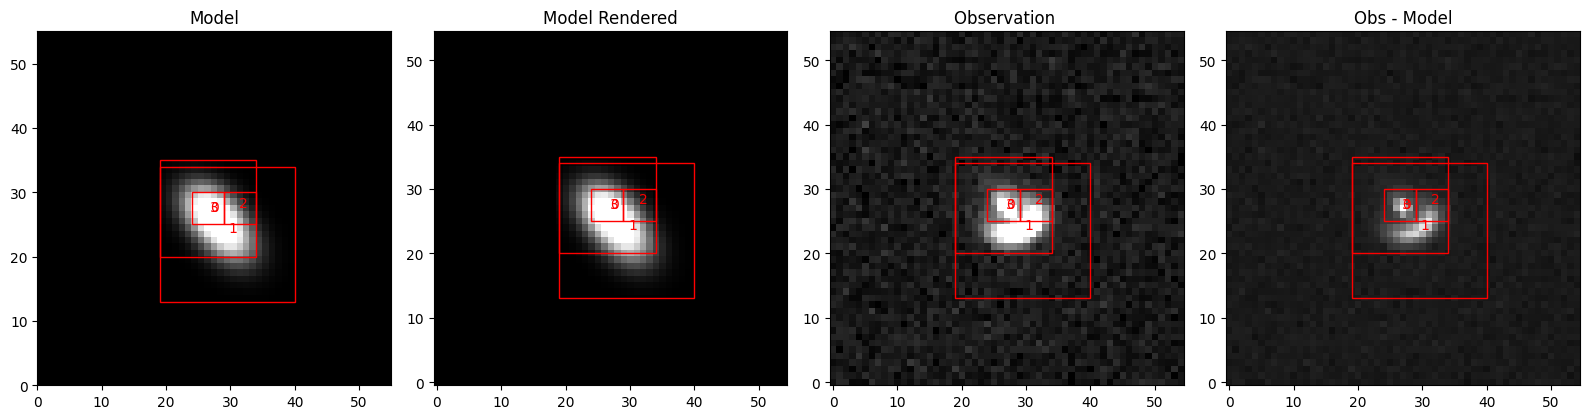

In [34]:
# Plot scene
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[50],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)


plt.show()

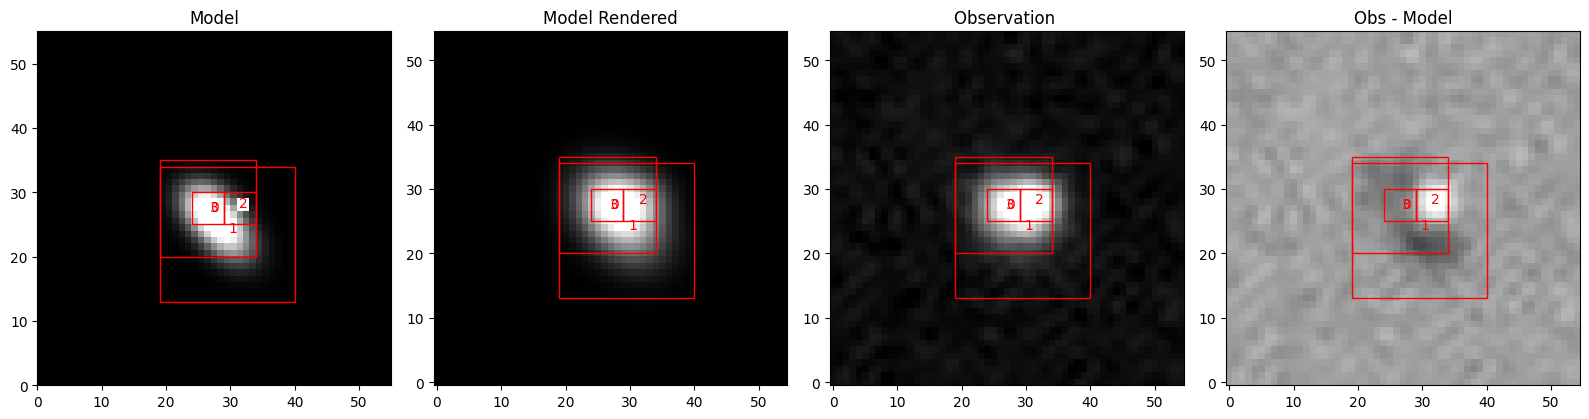

In [35]:
# Plot scene
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[40],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)


plt.show()

# Fitting

In [36]:
# pos_step = 5e-3                                                   # change if SN positions look bad
# morph_step = lambda p: scarlet2.relative_step(p, factor=1e-5)     # change factor if galaxies look bad
# SED_step = lambda p: scarlet2.relative_step(p, factor=1e-3)       # change factor if flux looks bad

pos_step = 8e-3
morph_step = lambda p: scarlet2.relative_step(p, factor=5e-6)
SED_step_SN = lambda p: scarlet2.relative_step(p, factor=1e-2)
SED_step_gal = lambda p: scarlet2.relative_step(p, factor=8e-4)


for i, obs in enumerate(observations_sc2):   # shift observations  
    obs.check_set_renderer(model_frame)
    with scarlet2.Parameters(obs):
        scarlet2.Parameter(obs.renderer[1].shift, name=f"shift_{i}", stepsize=1e-2  * u.arcsec)

    
with Parameters(scene):   
    for source_indx in range(len(scene.sources)):

        if is_extended[source_indx]:
            SED_step = SED_step_gal
        else:
            SED_step = SED_step_SN
        
        scarlet2.Parameter(scene.sources[source_indx].spectrum.data, 
                                         name=f"spectrum.{source_indx}", 
                                         stepsize=SED_step,
                                         constraint=constraints.positive,   
                                        ) 
    
        if is_extended[source_indx]:
            # Static host or lens galaxy parameters
            scarlet2.Parameter(scene.sources[source_indx].morphology,  
                                             name=f"morph.{source_indx}", stepsize=morph_step,
                                             constraint=constraints.positive)
            
        else:
            #Transient point source parameters
            scarlet2.Parameter(scene.sources[source_indx].center, 
                               name=f"center.{source_indx}",
                               stepsize=pos_step)
             
    

In [37]:
# for k, src in enumerate(scene.sources):
#     print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

In [38]:
# Fit the scene
stepnum = 15000
scene_, observations_sc2_ = scarlet2.fit(scene, observations_sc2, max_iter=stepnum, e_rel=1e-7, progress_bar=True) 


  0%|          | 0/15000 [00:00<?, ?it/s]

In [39]:
## Save the model
# import scarlet2.io as io
# id = int(str(img_index) + '6')
# filename = "scarlet2_caustics_models.h5"
# io.model_to_h5(scene_, filename, id=id, overwrite=True)

In [40]:
# using only the Jacobian tranform between the resampled and native HSC frame
# this ignores possible frame offset because the shift is relative
# get the astrometry shift
shift = observations_sc2_[0].get("shift")
print(f"Shift in model pixels: {shift}")

for i in range(len(observations_sc2)): #[:-n_roman])):

    shift_band = observations_sc2_[i].get(f"shift_{i}")
    print(f"Obs {i} shift in model pixels: {shift_band}")
    
    obs = observations_sc2[i]
    obs_ = observations_sc2_[i]

    jacobian, _ = scarlet2.frame.get_relative_jacobian_shift(obs_.frame, obs.frame)
    shift_native = jacobian @ shift_band
    # print(f"{i}: Shift in native pixels: {shift_native}")
    
    # create the renderer for native HSC if not already there
    obs.check_set_renderer(model_frame)
    # force the renderer to use optimized value for shift
    object.__setattr__(obs.renderer[-1], "shift", shift_native)
    



Shift in model pixels: None
Obs 0 shift in model pixels: [-0.17831935 -1.5365351 ]
Obs 1 shift in model pixels: [-0.33255216 -1.0033768 ]
Obs 2 shift in model pixels: [-0.26472995 -0.67507064]
Obs 3 shift in model pixels: [-0.0700323 -0.7160482]
Obs 4 shift in model pixels: [-0.1804227 -1.1794224]
Obs 5 shift in model pixels: [-0.07303538 -0.84650016]
Obs 6 shift in model pixels: [-0.20518766 -1.0026343 ]
Obs 7 shift in model pixels: [-0.1706548 -1.1448859]
Obs 8 shift in model pixels: [-0.01292809 -1.0038265 ]
Obs 9 shift in model pixels: [-0.1868269 -1.305853 ]
Obs 10 shift in model pixels: [-0.10802365 -1.1273454 ]
Obs 11 shift in model pixels: [-0.2728795 -1.0005511]
Obs 12 shift in model pixels: [ 0.05242151 -1.1532611 ]
Obs 13 shift in model pixels: [-0.26211992 -0.9775109 ]
Obs 14 shift in model pixels: [ 0.14148018 -1.2890823 ]
Obs 15 shift in model pixels: [ 0.15171562 -1.5274096 ]
Obs 16 shift in model pixels: [-0.24610503 -1.2035731 ]
Obs 17 shift in model pixels: [-0.274914

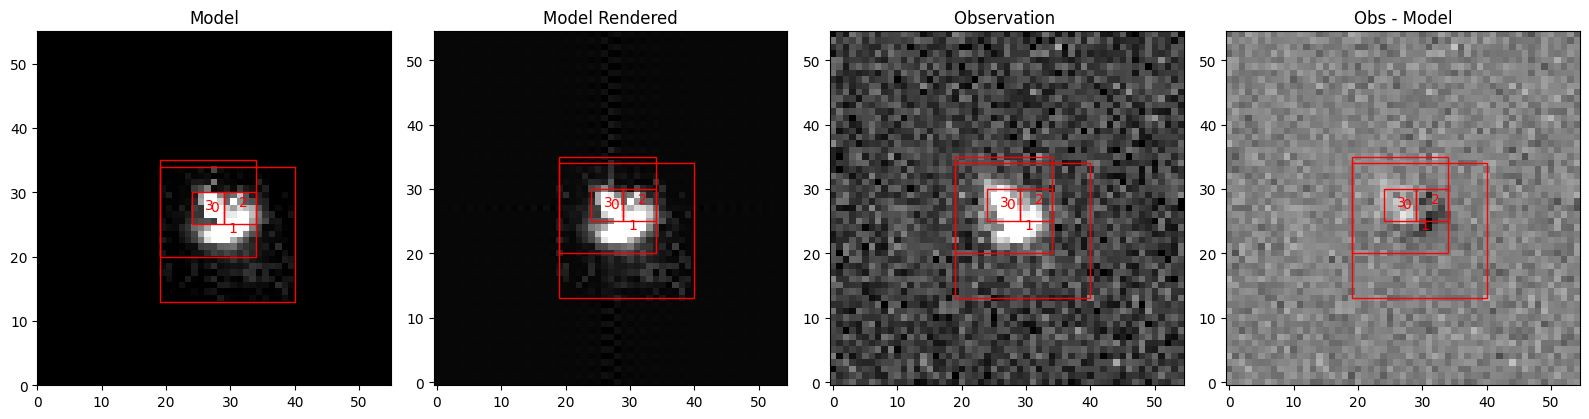

In [41]:
scarlet2.plot.scene(
    scene_,
    observation=observations_sc2[48],
    show_rendered=True,
    show_observed=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    norm=None,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)


plt.show()


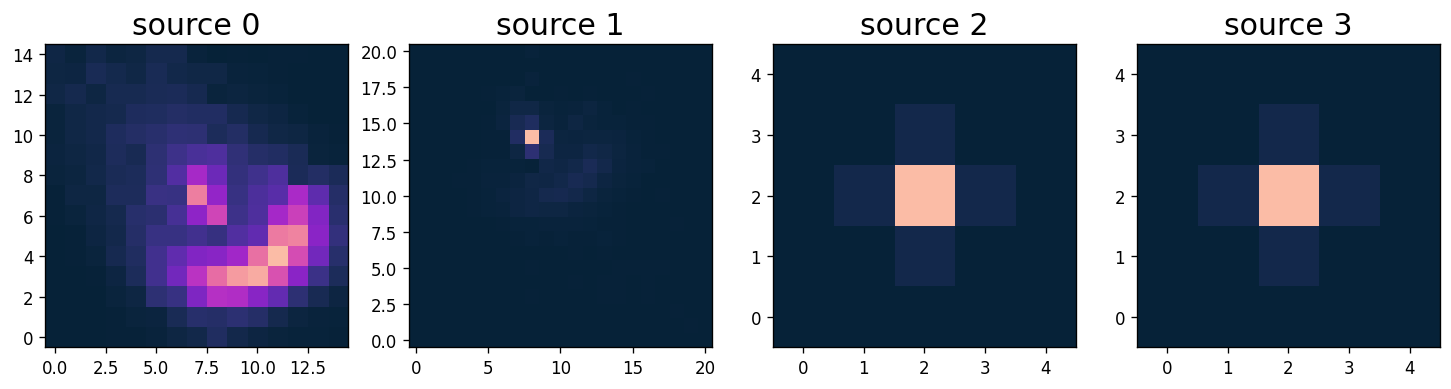

<Figure size 640x480 with 0 Axes>

In [42]:
cmap = cmr.bubblegum
int_method='none'
fig, axes = plt.subplots(1, len( scene_.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if is_extended[i]==True:
         y = np.array(scene_.sources[i].morphology)
    else:
        y = scene_.sources[i].morphology()
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)


plt.show()
plt.clf()

In [43]:
for k, src in enumerate(scene_.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

Source 0, Fluxes: [18.012375 18.012375 18.012375 18.012375 18.012375 18.012375 18.012375
 18.012375 18.012375 18.012375 18.012375 18.012375 18.012375 18.012375
 18.012375 18.012375 23.888342 23.888342 23.888342 23.888342 23.888342
 23.888342 23.888342 23.888342 23.888342 23.888342 23.888342 23.888342
 23.888342 23.888342 23.888342 23.888342 34.81796  34.81796  34.81796
 34.81796  34.81796  34.81796  34.81796  34.81796  34.81796  34.81796
 34.81796  34.81796  34.81796  34.81796  34.81796  34.81796   4.695913
 56.209106 85.921455  4.695913 56.209106 85.921455]
Source 1, Fluxes: [ 12.421806  12.421806  12.421806  12.421806  12.421806  12.421806
  12.421806  12.421806  12.421806  12.421806  12.421806  12.421806
  12.421806  12.421806  12.421806  12.421806  14.040974  14.040974
  14.040974  14.040974  14.040974  14.040974  14.040974  14.040974
  14.040974  14.040974  14.040974  14.040974  14.040974  14.040974
  14.040974  14.040974  23.590971  23.590971  23.590971  23.590971
  23.590971  23

In [44]:
# Save Rubin Point Source fluxes to pickle file for later use
import pickle

# Get indices of (band, epoch) for each Rubin band
band_epoch_indices = {band: [] for band in bands}
for idx, (band, epoch) in enumerate(channels):
    if band in bands:
        band_epoch_indices[band].append((int(epoch), idx))

# Get indices of point sources (is_extended == False)
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]
num_point_sources = len(point_source_indices)

# Determine the number of epochs per band
max_epochs = {
    band: max(epoch for epoch, _ in indices) + 1
    for band, indices in band_epoch_indices.items()
}

# Initialize output flux structure: bands × epochs × sources
flux_array = {
    band: [[0.0 for _ in range(num_point_sources)] for _ in range(max_epochs[band])]
    for band in bands
}

# Fill in the flux values for only point sources
for local_idx, src_idx in enumerate(point_source_indices):
    fluxes = scarlet2.measure.flux(scene_.sources[src_idx])
    for band in bands:
        for epoch, flux_idx in band_epoch_indices[band]:
            flux_array[band][epoch][local_idx] = fluxes[flux_idx]

# Convert to final nested array format
output_array = [flux_array[band] for band in bands]
print(output_array)

## Save to file
# file_path = 'fluxes_files/scarlet_deblended_flux/'
# with open(file_path+'rubin_scarlet_caustics_fluxes_'+str(img_index)+str(version)+'.pkl', "wb") as f:
#     pickle.dump(output_array, f)

[[[Array(0., dtype=float32), Array(0., dtype=float32)], [Array(1.3902727, dtype=float32), Array(1.6331, dtype=float32)], [Array(6.882778, dtype=float32), Array(3.2193778, dtype=float32)], [Array(5.25415, dtype=float32), Array(4.7436814, dtype=float32)], [Array(4.2811337, dtype=float32), Array(3.316397, dtype=float32)], [Array(1.6454016, dtype=float32), Array(6.0795536, dtype=float32)], [Array(1.0732732, dtype=float32), Array(3.5292606, dtype=float32)], [Array(0.00326955, dtype=float32), Array(2.8124895, dtype=float32)], [Array(0.00023324, dtype=float32), Array(2.064084, dtype=float32)], [Array(1.0751852, dtype=float32), Array(0.5543809, dtype=float32)], [Array(0.00063947, dtype=float32), Array(3.3321767, dtype=float32)], [Array(0.5766428, dtype=float32), Array(2.1511686, dtype=float32)], [Array(0.00036085, dtype=float32), Array(1.5027002, dtype=float32)], [Array(0.00044082, dtype=float32), Array(2.6510913, dtype=float32)], [Array(0., dtype=float32), Array(0., dtype=float32)], [Array(0.

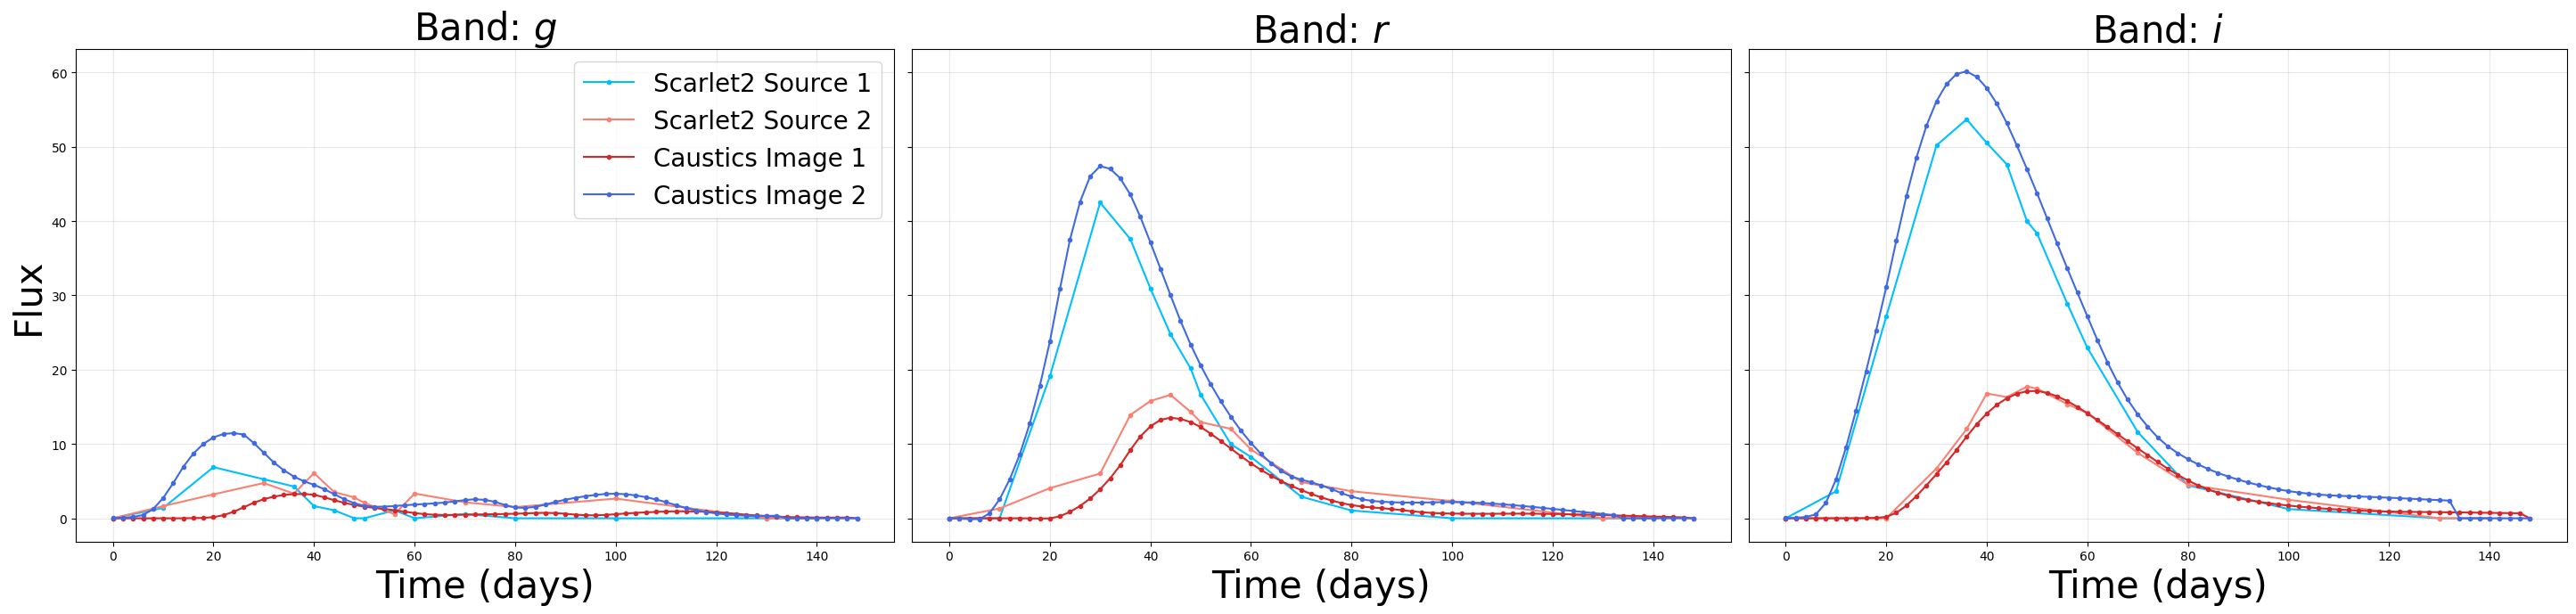

In [46]:
# Plot light curves and compare to Caustics (true) light curves
with open('fluxes_files/caustics_flux/caustics_fluxes_'+str(img_index)+'_14_04_26'+'.pkl', "rb") as caustics_f:
    caustics_fluxes = pickle.load(caustics_f)
caustics_times = np.arange(0, 150, 2) 
sc_times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]


fig, axes = plt.subplots(1, 3, figsize=(29, 7), sharey=True)
caustics_colors = ['tab:red', 'royalblue']
sc_colors = ['deepskyblue', 'salmon']
band_names_plot = [r'$g$', r'$r$', r'$i$']

for band_indx, band in enumerate(bands):
    ax = axes[band_indx]
    n_caustics_epochs = len(caustics_fluxes[band_indx])
    sc_epochs = sorted(set(epoch for epoch, _ in band_epoch_indices[band]))

    for local_idx in range(num_point_sources):
        sc_flux = np.array([flux_array[band][epoch][local_idx] for epoch in sc_epochs])
        ax.plot(sc_times, sc_flux, marker='o', markersize=3,
                label=f'Scarlet2 Source {local_idx+1}', color=sc_colors[local_idx])

    for local_idx in range(num_point_sources):
        caustics_flux = np.array([caustics_fluxes[band_indx][t][num_point_sources - 1 - local_idx]
                                  for t in range(n_caustics_epochs)])
        ax.plot(caustics_times, caustics_flux, marker='o', markersize=3,
                label=f'Caustics Image {local_idx+1}', color=caustics_colors[local_idx])

    ax.set_title(f'Band: {band_names_plot[band_indx]}', fontsize=30)
    ax.set_xlabel('Time (days)', fontsize=30)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Flux', fontsize=30)
axes[0].legend(loc='upper right', fontsize=20)
# fig.suptitle('System ' + str(img_index) + r', $\Delta t = $' + td, fontsize=30)
plt.tight_layout()
plt.show()